
# Linear Regression — Predicting Trends

### A complete beginner-friendly guide: Theory → Math → Hand Calculation → Code

---

In this notebook we will learn Linear Regression **from the ground up**. We won't touch code until the very end — first we build a rock-solid understanding of *what* it is, *why* it works, and *how the math behind it works*, including solving one entirely by hand.

**What we'll cover:**
1. What is Regression?
2. What is Linear Regression? (Definitions & Real-life analogy)
3. The Linear Equation (Simple & Multiple)
4. The Cost Function (Error Measurement)
5. How the model *learns* — Gradient Descent
6. The Normal Equation (Direct Math Solution)
7. **Solving Linear Regression by hand** on paper, with real numbers
8. Model Evaluation (R² Score)
9. Regularization — Ridge, Lasso, Elastic Net
10. Code — from a from-scratch implementation to an advanced version with regularization and error-tracking



## 1. What is Regression?

**Definition:** Regression is a supervised machine learning technique used to predict a **continuous numeric value** based on one or more input variables.

Think of the difference like this:

| Task | Type | Example |
|---|---|---|
| Predicting if an email is spam or not | Classification | Output: "Spam" / "Not Spam" |
| Predicting the price of a house | **Regression** | Output: ₹45,00,000 |
| Predicting tomorrow's temperature | **Regression** | Output: 32.5°C |

So, whenever the answer you want is a **number that can take any value** (not a category), you are doing regression.

**Why "trends"?** Regression finds the underlying *trend* or *pattern* connecting an input to an output, so that once we know the trend, we can predict the output for new, unseen inputs.



## 2. What is Linear Regression?

**Definition:** Linear Regression is the simplest regression technique. It assumes that the relationship between the input(s) and the output can be represented by a **straight line** (in 2D) or a **flat plane/hyperplane** (in higher dimensions).

### Real-life Analogy

Imagine you are tracking how many hours you study versus the marks you score in a test:

| Hours Studied | Marks Scored |
|---|---|
| 1 | 2 |
| 2 | 4 |
| 3 | 5 |
| 4 | 4 |
| 5 | 5 |

If you plot these points, they roughly seem to increase together — more hours, more marks. Linear Regression tries to draw the **single best straight line** through these points so that:

> Given a *new* number of study hours, we can predict the expected marks.

That "best straight line" is the entire goal of linear regression.

### Key Idea
We are not just connecting dots — we are finding **one line that best represents the overall trend**, minimizing how "wrong" it is across *all* the points at once.



## 3. The Linear Equation

### Simple Linear Regression (One Input Variable)

The equation of a straight line, which you've likely seen in school, is:

$$
y = mx + c
$$

In Machine Learning, we usually rewrite this using different symbols:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

**What each term means:**

| Symbol | Name | Meaning |
|---|---|---|
| $\hat{y}$ (y-hat) | Predicted output | The value our model predicts |
| $x$ | Input feature | The independent variable (e.g., hours studied) |
| $\beta_0$ (beta-zero) | Intercept | The value of $\hat{y}$ when $x = 0$ (where the line crosses the y-axis) |
| $\beta_1$ (beta-one) | Slope / Coefficient | How much $\hat{y}$ changes when $x$ increases by 1 unit |

**Intuition:** $\beta_1$ tells us the *steepness* of the trend. A large positive $\beta_1$ means the output increases quickly as input increases. A negative $\beta_1$ means the output decreases as input increases.

### Multiple Linear Regression (Many Input Variables)

Real-world problems usually have more than one input. For example, predicting house price using *size*, *location score*, and *number of rooms*. The equation extends naturally:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

This is the same idea — just more slopes ($\beta_1, \beta_2, \dots$), one for each input feature ($x_1, x_2, \dots$). Geometrically, instead of a line, this becomes a flat **hyperplane** cutting through a higher-dimensional space.

### The Catch: Real data is never *perfectly* on a line

In practice, our predicted value $\hat{y}$ will rarely match the actual value $y$ exactly. The difference is called the **error** or **residual**:

$$
e_i = y_i - \hat{y}_i
$$

Our entire job in Linear Regression is to choose $\beta_0$ and $\beta_1$ (and $\beta_2, \beta_3 \dots$ if there are more features) such that these errors are, on average, as small as possible.



## 4. The Cost Function — Measuring How Wrong We Are

**Definition:** A **Cost Function** (also called a **Loss Function**) is a formula that measures how far off our model's predictions are from the actual values. Training a model = finding parameters that make this cost as small as possible.

### Why not just add up the errors?

You might think: just add all errors $e_i = y_i - \hat{y}_i$ together and try to make that zero. But this fails because **positive and negative errors cancel out**. A model that is wildly wrong (some points way above the line, some way below) could still show a total error of zero — which is misleading.

### Solution: Mean Squared Error (MSE)

We square every error before adding them. Squaring does two useful things:
- Makes every error **positive** (no cancellation)
- **Penalizes large errors more** than small ones (since squaring grows fast)

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

**Breaking the formula down:**

| Symbol | Meaning |
|---|---|
| $n$ | Total number of data points |
| $y_i$ | Actual value for the $i$-th data point |
| $\hat{y}_i$ | Predicted value for the $i$-th data point |
| $(y_i - \hat{y}_i)^2$ | Squared error for that single point |
| $\sum$ | Sum over all data points |
| $\frac{1}{n}$ | Averaging — so cost doesn't just grow because we have more data |

In ML papers, you'll often see this same idea written using a slightly different constant, called the **Cost Function** $J$:

$$
J(\beta_0, \beta_1) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

**Why the extra $\frac{1}{2}$?** It's purely a mathematical convenience. When we differentiate this function later (for Gradient Descent), the power of 2 (from squaring) comes down and cancels with this $\frac{1}{2}$, leaving clean formulas. It does *not* change which $\beta_0, \beta_1$ minimize the cost.

### The Goal, Formally

$$
\min_{\beta_0, \beta_1} \; J(\beta_0, \beta_1)
$$

In words: *find the values of $\beta_0$ and $\beta_1$ that make the cost function $J$ as small as possible.*

There are two classic ways to solve this:
1. **Gradient Descent** — an iterative, trial-and-improve search
2. **Normal Equation** — a direct, one-shot algebraic solution

We'll understand both.



## 5. How the Model Learns — Gradient Descent

**Definition:** Gradient Descent is an optimization algorithm that gradually adjusts the parameters ($\beta_0, \beta_1$) in small steps, always moving in the direction that **reduces the cost function**, until it settles at (or near) the minimum.

### Intuition: Walking Downhill in the Fog

Imagine you're standing on a hill (representing the cost function) in thick fog, and you want to reach the lowest point of the valley. You can't see the whole landscape, but you can *feel* the slope under your feet. So you take a small step in the steepest downhill direction, feel the new slope, take another step, and repeat. Eventually, you reach the bottom.

- The "hill" = the cost function $J(\beta_0, \beta_1)$
- "Feeling the slope" = calculating the **gradient** (derivative) of $J$
- "Taking a step" = updating $\beta_0, \beta_1$ slightly

### The Gradient (Slope) of the Cost Function

The gradient tells us the direction of steepest **increase**. Since we want to *decrease* the cost, we move in the *opposite* direction of the gradient.

Taking partial derivatives of $J(\beta_0, \beta_1)$ with respect to each parameter:

$$
\frac{\partial J}{\partial \beta_0} = -\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)
$$

$$
\frac{\partial J}{\partial \beta_1} = -\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i) \cdot x_i
$$

Don't worry about deriving these — just understand what they represent: **the direction and rate at which the cost changes** if we nudge $\beta_0$ or $\beta_1$ slightly.

### The Update Rule

At every step, we update our parameters like this:

$$
\beta_0 := \beta_0 - \alpha \frac{\partial J}{\partial \beta_0}
$$

$$
\beta_1 := \beta_1 - \alpha \frac{\partial J}{\partial \beta_1}
$$

**What each term means:**

| Symbol | Meaning |
|---|---|
| $:=$ | "gets updated to" (assignment) |
| $\alpha$ (alpha) | **Learning Rate** — how big a step we take each time |
| $\frac{\partial J}{\partial \beta_0}, \frac{\partial J}{\partial \beta_1}$ | The gradients (slopes) computed above |

### Why the Learning Rate Matters

- **Too small $\alpha$:** learning is extremely slow — like taking tiny baby steps downhill, it'll take forever.
- **Too large $\alpha$:** you might overshoot the minimum and bounce around, or even diverge (cost increases instead of decreasing).
- **Just right:** the cost decreases smoothly and steadily until it flattens out — this flattening means we've reached (or nearly reached) the minimum.

This whole process — compute gradient, update parameters, repeat — is done for many rounds, called **epochs** or **iterations**, until the cost stops improving meaningfully.



## 6. The Normal Equation — A Direct Math Solution

Gradient Descent finds the best line **step by step**. But for Linear Regression specifically, there's also a way to jump **directly** to the exact best-fit line using algebra — no iterations needed. This is called the **Normal Equation**.

### For Simple Linear Regression (One Feature)

The optimal slope and intercept can be computed directly using these formulas:

$$
\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

$$
\beta_0 = \bar{y} - \beta_1 \bar{x}
$$

**What each term means:**

| Symbol | Meaning |
|---|---|
| $\bar{x}$ (x-bar) | The **mean (average)** of all $x$ values |
| $\bar{y}$ (y-bar) | The **mean (average)** of all $y$ values |
| $(x_i - \bar{x})$ | How far each $x$ value is from the average (deviation) |
| $(y_i - \bar{y})$ | How far each $y$ value is from the average (deviation) |
| Numerator | Measures how $x$ and $y$ move **together** (covariance-like term) |
| Denominator | Measures how spread out $x$ is (variance-like term) |

**Intuition:** The slope $\beta_1$ is essentially asking: *"On average, when x moves away from its mean, how much does y move away from its mean, in the same direction?"* This is exactly the idea behind **covariance divided by variance**.

### For Multiple Linear Regression (Matrix Form)

When there are many features, we use matrix notation for compactness:

$$
\boldsymbol{\beta} = (X^T X)^{-1} X^T y
$$

Where:
- $X$ is the matrix of all input features (with an extra column of 1's for the intercept)
- $y$ is the vector of actual outputs
- $X^T$ is the transpose of $X$
- $(X^T X)^{-1}$ is the matrix inverse

This single formula computes **all** the best-fit coefficients at once. We won't derive this fully here (it comes from setting the gradient of the cost function to zero and solving), but it's good to know it exists — it's what many libraries use internally for smaller datasets.

**Gradient Descent vs Normal Equation — when to use which:**

| | Gradient Descent | Normal Equation |
|---|---|---|
| Works well for | Large datasets, many features | Small/medium datasets |
| Needs learning rate $\alpha$? | Yes | No |
| Iterative? | Yes | No (direct formula) |
| Computational cost | Cheap per step, many steps | Expensive matrix inversion for many features |



## 7. Solving Linear Regression *By Hand* — A Worked Example

Let's actually compute a linear regression line **using pen-and-paper math**, with no code at all, using our earlier study-hours example.

### The Data

| $x$ (Hours Studied) | $y$ (Marks Scored) |
|---|---|
| 1 | 2 |
| 2 | 4 |
| 3 | 5 |
| 4 | 4 |
| 5 | 5 |

We want to find $\beta_0$ and $\beta_1$ in $\hat{y} = \beta_0 + \beta_1 x$ using the Normal Equation formulas from Section 6.

---

### Step 1: Calculate the Means

$$
\bar{x} = \frac{1+2+3+4+5}{5} = \frac{15}{5} = 3
$$

$$
\bar{y} = \frac{2+4+5+4+5}{5} = \frac{20}{5} = 4
$$

---

### Step 2: Calculate Deviations from the Mean

| $x_i$ | $y_i$ | $x_i - \bar{x}$ | $y_i - \bar{y}$ |
|---|---|---|---|
| 1 | 2 | $1-3=-2$ | $2-4=-2$ |
| 2 | 4 | $2-3=-1$ | $4-4=0$ |
| 3 | 5 | $3-3=0$ | $5-4=1$ |
| 4 | 4 | $4-3=1$ | $4-4=0$ |
| 5 | 5 | $5-3=2$ | $5-4=1$ |

---

### Step 3: Multiply Deviations (Numerator terms) and Square $x$ Deviations (Denominator terms)

| $(x_i-\bar{x})(y_i-\bar{y})$ | $(x_i-\bar{x})^2$ |
|---|---|
| $(-2)(-2) = 4$ | $(-2)^2 = 4$ |
| $(-1)(0) = 0$ | $(-1)^2 = 1$ |
| $(0)(1) = 0$ | $(0)^2 = 0$ |
| $(1)(0) = 0$ | $(1)^2 = 1$ |
| $(2)(1) = 2$ | $(2)^2 = 4$ |
| **Sum = 6** | **Sum = 10** |

---

### Step 4: Compute the Slope $\beta_1$

$$
\beta_1 = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2} = \frac{6}{10} = 0.6
$$

---

### Step 5: Compute the Intercept $\beta_0$

$$
\beta_0 = \bar{y} - \beta_1 \bar{x} = 4 - (0.6)(3) = 4 - 1.8 = 2.2
$$

---

### Step 6: Write the Final Regression Equation

$$
\boxed{\hat{y} = 2.2 + 0.6x}
$$

**Interpretation:**
- $\beta_0 = 2.2$: if a student studies 0 hours, the model predicts a score of 2.2
- $\beta_1 = 0.6$: for every extra hour studied, the predicted marks increase by 0.6

---

### Step 7: Verify with Predictions and Compute Error (MSE)

| $x_i$ | $y_i$ (actual) | $\hat{y}_i = 2.2+0.6x_i$ (predicted) | $e_i = y_i - \hat{y}_i$ | $e_i^2$ |
|---|---|---|---|---|
| 1 | 2 | $2.2+0.6=2.8$ | $2-2.8=-0.8$ | $0.64$ |
| 2 | 4 | $2.2+1.2=3.4$ | $4-3.4=0.6$ | $0.36$ |
| 3 | 5 | $2.2+1.8=4.0$ | $5-4.0=1.0$ | $1.00$ |
| 4 | 4 | $2.2+2.4=4.6$ | $4-4.6=-0.6$ | $0.36$ |
| 5 | 5 | $2.2+3.0=5.2$ | $5-5.2=-0.2$ | $0.04$ |

$$
MSE = \frac{0.64+0.36+1.00+0.36+0.04}{5} = \frac{2.4}{5} = 0.48
$$

So this particular line has a Mean Squared Error of **0.48**. Any other choice of $\beta_0, \beta_1$ would give an MSE **equal to or greater** than this — because our formulas mathematically guarantee the minimum possible squared error. This is the whole point of the Normal Equation: it doesn't guess — it computes the exact best line directly.

We now have a complete, verified-by-hand linear regression model — before writing a single line of code!



## 8. Evaluating the Model — R² Score

Once we have a line, how do we know if it's actually *good*? MSE alone is hard to interpret because its scale depends on the units of $y$ (e.g., MSE of 0.48 for marks vs MSE of 4800000 for house prices — both could represent similarly "good" fits, but the raw numbers look totally different).

### R-Squared ($R^2$) — Coefficient of Determination

**Definition:** $R^2$ tells us **what proportion of the variation in $y$ is explained by our model**, on a scale that's always between 0 and 1 (sometimes negative for very poor models).

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

**Breaking it down:**

| Term | Meaning |
|---|---|
| $\sum(y_i-\hat{y}_i)^2$ | **Residual Sum of Squares (SSR)** — error left over after our model's predictions |
| $\sum(y_i-\bar{y})^2$ | **Total Sum of Squares (SST)** — error if we had just predicted the average $\bar{y}$ every time (a "do-nothing" baseline model) |

**Intuition:** We're comparing our model's error to the error of the simplest possible baseline (always guessing the average). If our model is much better than this baseline, the ratio $\frac{SSR}{SST}$ is small, so $R^2$ is close to **1** (excellent fit). If our model is no better than just guessing the average, $R^2$ is close to **0**.

- $R^2 = 1$: Perfect fit, model explains 100% of variation
- $R^2 = 0$: Model is no better than predicting the mean every time
- $R^2 < 0$: Model is *worse* than just predicting the mean (a bad sign!)



## 9. Regularization — Preventing Overfitting

### The Problem: Overfitting

When we have many features, or noisy data, plain Linear Regression can start fitting the **noise** in the training data rather than the true underlying trend. This is called **overfitting** — the model performs great on training data but poorly on new, unseen data, because the coefficients ($\beta$ values) become too large and too sensitive to small fluctuations.

### The Solution: Add a Penalty for Large Coefficients

Regularization modifies the cost function by **adding a penalty term** that discourages large $\beta$ values, forcing the model to stay simpler and more general.

### Ridge Regression (L2 Regularization)

$$
J_{ridge}(\beta) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 \; + \; \lambda \sum_{j=1}^{p} \beta_j^2
$$

**New term explained:**

| Symbol | Meaning |
|---|---|
| $\lambda$ (lambda) | **Regularization strength** — controls how much we penalize large coefficients |
| $\sum \beta_j^2$ | Sum of the **squares** of all coefficients (excluding $\beta_0$) |

**Intuition:** Squaring the coefficients and adding them to the cost means the model is now "punished" for having large weights. It will shrink coefficients towards zero, but rarely all the way to exactly zero. This keeps *all* features in the model, just with smaller influence — good when you believe most features are somewhat useful.

### Lasso Regression (L1 Regularization)

$$
J_{lasso}(\beta) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 \; + \; \lambda \sum_{j=1}^{p} |\beta_j|
$$

**Difference from Ridge:** Instead of squaring the coefficients, we take their **absolute value**. This subtle change has a big effect: Lasso can shrink some coefficients **all the way to exactly zero**, effectively **removing** those features from the model entirely. This makes Lasso useful for automatic **feature selection**.

### Elastic Net — Best of Both Worlds

$$
J_{elastic}(\beta) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 \; + \; \lambda \left( r\sum_{j=1}^{p}|\beta_j| + (1-r)\sum_{j=1}^{p}\beta_j^2 \right)
$$

Here, $r$ (a value between 0 and 1) blends the L1 and L2 penalties — giving both the feature-selection ability of Lasso and the stability of Ridge.

### Summary Table

| Method | Penalty | Effect on Coefficients | Best When |
|---|---|---|---|
| Plain Linear Regression | None | No shrinkage | Few features, low noise |
| Ridge (L2) | $\sum \beta_j^2$ | Shrinks towards 0 (rarely exactly 0) | Many correlated features |
| Lasso (L1) | $\sum \lvert\beta_j\rvert$ | Can shrink exactly to 0 (feature selection) | Suspect many irrelevant features |
| Elastic Net | Mix of L1 & L2 | Blend of both behaviors | Many features, some correlated |



## 10. Code — From Scratch to Advanced

Now that we deeply understand the theory and math, let's implement it in code. We will build up in stages:

1. **Basic:** Implement Simple Linear Regression completely from scratch using the Normal Equation formulas we solved by hand
2. **Gradient Descent version:** Implement it from scratch using iterative Gradient Descent, and track how the error (cost) reduces over iterations
3. **Using `scikit-learn`:** The industry-standard way, exploring key parameters (`fit_intercept`, `positive`, multiple features)
4. **Advanced:** Compare Ridge, Lasso, and Elastic Net regularized regression, visualize how coefficients shrink, and track train-vs-test error to see overfitting/underfitting in action

Let's start coding.


In [1]:

# ============================================================
# STAGE 1: Linear Regression FROM SCRATCH using Normal Equation
# (This reproduces the exact hand-calculation we did on paper)
# ============================================================
import numpy as np

# Our study-hours dataset from the hand-worked example
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

# Step 1: Means
x_mean = np.mean(x)
y_mean = np.mean(y)

# Step 2 & 3: Deviations, products, and squares
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)

# Step 4 & 5: Slope and Intercept
beta_1 = numerator / denominator
beta_0 = y_mean - beta_1 * x_mean

print(f"Slope (beta_1):     {beta_1}")
print(f"Intercept (beta_0): {beta_0}")
print(f"Regression Equation: y_hat = {beta_0} + {beta_1} * x")

# Predictions and Mean Squared Error (matches our hand calculation: MSE = 0.48)
y_pred = beta_0 + beta_1 * x
mse = np.mean((y - y_pred) ** 2)
print(f"Predictions: {y_pred}")
print(f"MSE: {mse}")


Slope (beta_1):     0.6
Intercept (beta_0): 2.2
Regression Equation: y_hat = 2.2 + 0.6 * x
Predictions: [2.8 3.4 4.  4.6 5.2]
MSE: 0.47999999999999987


In [2]:

# ============================================================
# STAGE 2: Linear Regression FROM SCRATCH using Gradient Descent
# We track the cost at every iteration to SEE the error reducing
# ============================================================
import numpy as np

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)
n = len(x)

# Initialize parameters (start with a random/simple guess)
beta_0, beta_1 = 0.0, 0.0
alpha = 0.05        # learning rate
epochs = 1000       # number of iterations
cost_history = []   # to track how error reduces over time

for epoch in range(epochs):
    y_pred = beta_0 + beta_1 * x
    error = y - y_pred

    # Cost function (MSE-based, matches our earlier formula)
    cost = np.mean(error ** 2)
    cost_history.append(cost)

    # Gradients (partial derivatives derived earlier)
    d_beta_0 = -(2/n) * np.sum(error)
    d_beta_1 = -(2/n) * np.sum(error * x)

    # Update rule: move opposite to the gradient
    beta_0 -= alpha * d_beta_0
    beta_1 -= alpha * d_beta_1

print(f"Learned Slope (beta_1):     {beta_1:.4f}")
print(f"Learned Intercept (beta_0): {beta_0:.4f}")
print(f"Final Cost (MSE):           {cost_history[-1]:.4f}")
print("\\nNotice these values converge very close to our hand-calculated")
print("beta_1 = 0.6, beta_0 = 2.2, MSE = 0.48 -- proving Gradient Descent")
print("arrives at (almost) the same answer as the direct Normal Equation!")


Learned Slope (beta_1):     0.6000
Learned Intercept (beta_0): 2.2000
Final Cost (MSE):           0.4800
\nNotice these values converge very close to our hand-calculated
beta_1 = 0.6, beta_0 = 2.2, MSE = 0.48 -- proving Gradient Descent
arrives at (almost) the same answer as the direct Normal Equation!


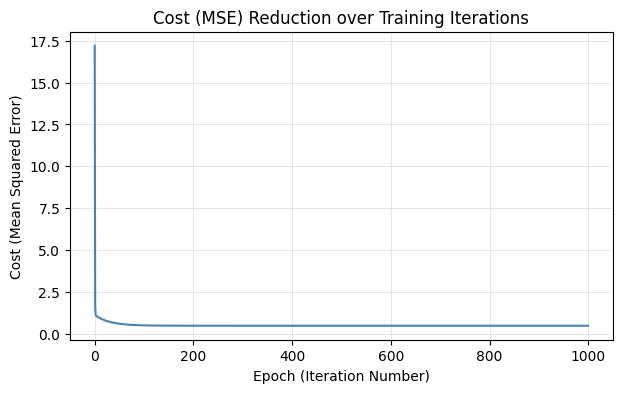

In [3]:

# ------------------------------------------------------------
# Visualizing the error (cost) reducing over iterations
# This plot is essential to SEE gradient descent converging
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(cost_history, color="steelblue")
plt.title("Cost (MSE) Reduction over Training Iterations")
plt.xlabel("Epoch (Iteration Number)")
plt.ylabel("Cost (Mean Squared Error)")
plt.grid(alpha=0.3)
plt.show()


In [4]:

# ============================================================
# STAGE 3: Using scikit-learn's LinearRegression
# Exploring different available parameters
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)   # sklearn expects 2D input for features
y = np.array([2, 4, 5, 4, 5])

# --- Default model (fit_intercept=True by default) ---
model = LinearRegression(fit_intercept=True)
model.fit(X, y)

print("Default model:")
print(f"  Intercept (beta_0): {model.intercept_:.4f}")
print(f"  Slope (beta_1):     {model.coef_[0]:.4f}")

y_pred = model.predict(X)
print(f"  MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"  R^2 Score: {r2_score(y, y_pred):.4f}")

# --- Parameter: fit_intercept=False forces the line through origin (beta_0 = 0) ---
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(X, y)
print("\\nModel with fit_intercept=False (forces line through origin):")
print(f"  Intercept: {model_no_intercept.intercept_}")
print(f"  Slope:     {model_no_intercept.coef_[0]:.4f}")

# --- Parameter: positive=True forces all coefficients to be non-negative ---
model_positive = LinearRegression(positive=True)
model_positive.fit(X, y)
print("\\nModel with positive=True (coefficients constrained to be >= 0):")
print(f"  Intercept: {model_positive.intercept_:.4f}")
print(f"  Slope:     {model_positive.coef_[0]:.4f}")


Default model:
  Intercept (beta_0): 2.2000
  Slope (beta_1):     0.6000
  MSE: 0.4800
  R^2 Score: 0.6000
\nModel with fit_intercept=False (forces line through origin):
  Intercept: 0.0
  Slope:     1.2000
\nModel with positive=True (coefficients constrained to be >= 0):
  Intercept: 2.2000
  Slope:     0.6000


In [5]:

# ------------------------------------------------------------
# Multiple Linear Regression example (more than one feature)
# Predicting exam score using Hours Studied AND Hours Slept
# ------------------------------------------------------------
from sklearn.linear_model import LinearRegression
import numpy as np

# Columns: [Hours Studied, Hours Slept]
X_multi = np.array([
    [1, 6],
    [2, 7],
    [3, 5],
    [4, 8],
    [5, 6]
])
y_multi = np.array([2, 4, 5, 4, 5])

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print(f"Intercept (beta_0): {multi_model.intercept_:.4f}")
print(f"Coefficients (beta_1 for Hours Studied, beta_2 for Hours Slept): {multi_model.coef_}")

# Predict for a NEW student: studied 3.5 hours, slept 7 hours
new_student = np.array([[3.5, 7]])
prediction = multi_model.predict(new_student)
print(f"Predicted score for a student who studied 3.5 hrs and slept 7 hrs: {prediction[0]:.2f}")


Intercept (beta_0): 4.1137
Coefficients (beta_1 for Hours Studied, beta_2 for Hours Slept): [ 0.63137255 -0.31372549]
Predicted score for a student who studied 3.5 hrs and slept 7 hrs: 4.13


In [6]:

# ============================================================
# STAGE 4: ADVANCED -- Ridge, Lasso, and Elastic Net
# Comparing regularization methods and how they shrink coefficients
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression
import numpy as np

# Create a synthetic dataset with MANY features, some of which are noise
# (n_informative=5 means only 5 of the 15 features actually matter)
X, y = make_regression(
    n_samples=200,
    n_features=15,
    n_informative=5,
    noise=15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2, alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (L1, alpha=1.0)": Lasso(alpha=1.0),
    "Elastic Net (l1_ratio=0.5, alpha=1.0)": ElasticNet(alpha=1.0, l1_ratio=0.5),
}

print(f"{'Model':<38}{'Train MSE':>12}{'Test MSE':>12}{'Test R2':>10}")
print("-" * 72)

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    train_pred = mdl.predict(X_train)
    test_pred = mdl.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    results[name] = mdl.coef_
    print(f"{name:<38}{train_mse:>12.2f}{test_mse:>12.2f}{test_r2:>10.3f}")


Model                                    Train MSE    Test MSE   Test R2
------------------------------------------------------------------------
Linear Regression                           211.08      175.36     0.995
Ridge (L2, alpha=1.0)                       212.51      166.84     0.995
Lasso (L1, alpha=1.0)                       220.15      165.56     0.995
Elastic Net (l1_ratio=0.5, alpha=1.0)      3675.56     5334.96     0.847


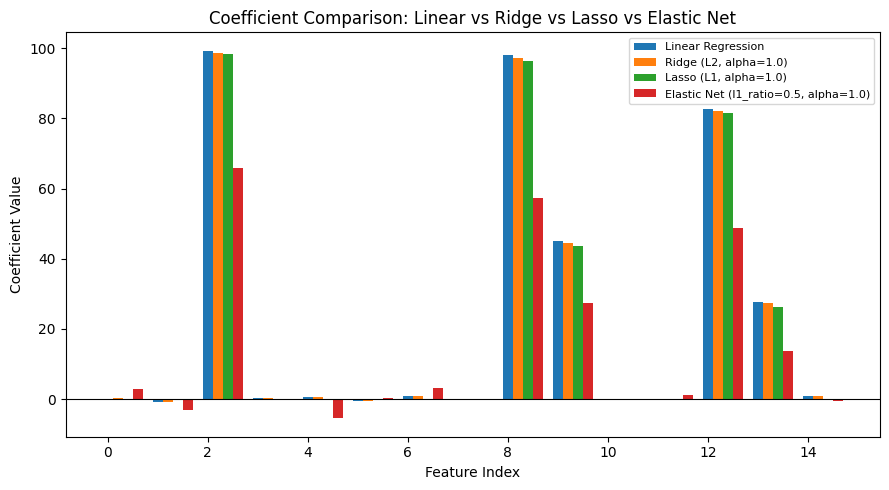

In [7]:

# ------------------------------------------------------------
# Visualizing how each method shrinks (or zeroes out) coefficients
# Notice Lasso pushes many coefficients to exactly 0 (feature selection!)
# while Ridge shrinks them but keeps them non-zero.
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))
feature_indices = np.arange(X.shape[1])
width = 0.2

for i, (name, coefs) in enumerate(results.items()):
    ax.bar(feature_indices + i * width, coefs, width=width, label=name)

ax.set_xlabel("Feature Index")
ax.set_ylabel("Coefficient Value")
ax.set_title("Coefficient Comparison: Linear vs Ridge vs Lasso vs Elastic Net")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



---
## Wrap-Up: What We Learned

- Regression predicts continuous numeric trends; Linear Regression assumes the trend is a straight line/hyperplane.
- The **Cost Function (MSE)** measures how wrong our predictions are, and training means minimizing this cost.
- **Gradient Descent** finds the minimum step-by-step by following the slope downhill; the **Normal Equation** finds it directly through algebra.
- We solved a full linear regression **by hand**, and confirmed our code (both the Normal Equation version and the Gradient Descent version) reproduces the exact same result.
- **R²** tells us how well our model explains the variation in data compared to a "just guess the average" baseline.
- **Regularization** (Ridge, Lasso, Elastic Net) helps prevent overfitting by penalizing overly large coefficients, with Lasso additionally performing automatic feature selection.
